In [1]:
import os
import math
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from graphcast.model_utils import stacked_to_dataset
from graphcast.losses import normalized_latitude_weights
from graphufs.stacked_utils import get_channel_index
from graphufs.datasets import Dataset
from prototypes.ocn_only.emulator import OcnEvaluator, OcnTrainer
from scipy import stats

In [2]:
plt.style.use("graphufs.plotstyle")

In [3]:
def persistence_fcast(model_type:str, prototype:str, eval_dates:list[str], num_missing_samples:int, fcast_nhours="240h"):

    #### SETUP ####
    emulator = OcnEvaluator(prototype)
    preserved_dims = ("batch", "lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the validation data
    valid_dir = f"{emulator.local_store_path}/validation"
    validation_inputs = xr.open_zarr(f"{valid_dir}/inputs.zarr")["inputs"] # (sample, lat, lon, channels)

    # Calculate the date ranges and find the integer indices for slicing
    validation_datetime = pd.date_range(
        start=pd.to_datetime(emulator.validation_dates[0]),
        end=(pd.to_datetime(emulator.validation_dates[1]) - 
             pd.Timedelta(emulator.delta_t_model)) - num_missing_samples*pd.Timedelta(emulator.delta_t_data),
        freq=pd.Timedelta(emulator.delta_t_data),
        inclusive="both",
    )
    
    # check the length of the validation dataset = validation datetime
    assert len(validation_datetime)==validation_inputs.sizes["sample"], \
    f"Error: Length of the time stamp vector and validation inputs did not match: {len(validation_datetime)}, {validation_inputs.sizes['sample']}"

    idx_start = validation_datetime.get_loc(pd.to_datetime(eval_dates[0]))
    idx_end = validation_datetime.get_loc(pd.to_datetime(eval_dates[1]))

    # Select the evaluation data and rename 'sample' to 'batch' for consistency
    eval_inputs = validation_inputs.sel(sample=slice(idx_start, idx_end, emulator.sample_stride)
    ).rename({"sample": "batch"}) # (batch=292, lat, lon, channels)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )

    # assert the lengths of the eval datetime vector and the eval dataset
    assert len(eval_datetime)==eval_inputs.sizes["batch"], \
    f"Error: Length of the eval datetime vector and eval inputs did not match:" \
    f"{len(eval_datetime)}, {eval_inputs.sizes['batch']}"

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
    meta_xinputs = get_channel_index(xinputs)

    for variable in xinputs.data_vars:
        dims_to_ensure = preserved_dims #tuple(d for d in preserved_dims if d != "batch")
        dims_not_present = [d for d in dims_to_ensure if d not in xinputs[variable].dims]
        for dimen in dims_not_present:
            xinputs[variable] = xinputs[variable].expand_dims(dim={dimen:eval_inputs.coords[dimen]})
        # make sure that the batch dimension has the same size in both datasets. Actually all
        # preserved dims must have the same size in both.
        if xinputs.sizes["batch"] != eval_inputs.sizes["batch"]:
            xinputs = xinputs.reindex({"batch":eval_inputs.coords["batch"]}, method="pad")
        xinputs[variable] = xinputs[variable].transpose("batch", ..., "lat", "lon")

    #### UNSTACK VALIDATION DATA ####
    # Only consider the input channels, not forcing. Note that xinputs would not have
    # forcing channels appended at the end. Just choose the inputs because the mapping
    # is only for inputs and this is what we need essentially.
    eval_inputs = eval_inputs.isel(channels=slice(None, len(meta_xinputs)))

    # Unstack the data by passing the underlying .variable object
    eval_inputs_unstacked = stacked_to_dataset(eval_inputs.variable, 
                                               xinputs, preserved_dims=preserved_dims)
    
    # now return the persistence in the same form as targets
    ds_persistence_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    for variable in xtargets.data_vars:
        var = eval_inputs_unstacked[variable].isel(time=-1, drop=True)
        var = var.rename(batch="time").assign_coords(time=eval_datetime)
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_persistence_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_persistence_fcast

In [4]:
def climatology(model_type:str, prototype:str):

    #### SETUP ####
    ocn_only_home = f"/global/homes/n/nagarwal/graph-ufs/prototypes/{model_type}"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
    preserved_dims = ("lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the training data
    train_dir = f"{emulator.local_store_path}/training"
    training_targets = xr.open_zarr(f"{train_dir}/targets.zarr")["targets"] # (sample, lat, lon, channels)

    # climatology
    climatology = training_targets.mean(dim="sample") # (lat, lon, channels)

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)

    #### UNSTACK CLIMATOLOGY ####
    clima_unstacked = stacked_to_dataset(climatology.variable, 
                                         xtargets.isel(batch=0, time=0, drop=True), 
                                         preserved_dims=preserved_dims)
    return clima_unstacked

In [5]:
def climatology_fcast(model_type:str, prototype:str, eval_dates:list[str], fcast_nhours="240h"):

    # Compute the climatology
    clima_unstacked = climatology(model_type, prototype).compute()

    #### SETUP ####
    ocn_only_home = f"/global/homes/n/nagarwal/graph-ufs/prototypes/{model_type}"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
    
    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
    
    # now return the persistence in the same form as targets
    ds_clima_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )
    print("climatology():eval_datetime", eval_datetime)
    
    for variable in xtargets.data_vars:
        var = clima_unstacked[variable]
        var = var.expand_dims(dim={"time": eval_datetime})
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_clima_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_clima_fcast

In [6]:
def climatology_monthly_mean(model_type: str, prototype: str):
    
    #### SETUP ####
    ocn_only_home = f"/global/homes/n/nagarwal/graph-ufs/prototypes/{model_type}"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
 
    preserved_dims = ("lat", "lon")
 
    #### LOAD AND PREPARE THE STACKED DATA ####
    train_dir = f"{emulator.local_store_path}/training"
 
    # CHANGED: keep open_zarr lazy (no .compute() yet), and cast to float32
    # immediately to halve memory vs float64 for all subsequent operations
    training_targets = xr.open_zarr(f"{train_dir}/targets.zarr")["targets"]
 
    # Build datetime index for training samples to extract month
    train_datetime = pd.date_range(
        start=pd.to_datetime(emulator.training_dates[0]),
        end=pd.to_datetime(emulator.training_dates[1]) - pd.Timedelta(emulator.delta_t_model),
        freq=pd.Timedelta(emulator.delta_t_data),
        inclusive="both",
    )
 
    assert len(train_datetime) == training_targets.sizes["sample"], \
        "Mismatch between training datetime vector and training targets"
 
    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
 
    #### UNSTACK EACH MONTH ####
    # Here, we compute each month's mean independently by selecting only 
    # that month's samples. This reduces peak memory from (all training 
    # samples) to (one month of training samples) at any given time, roughly 
    # a 12x reduction for this step.
    monthly_clima_unstacked = {}
    for m in range(1, 13):
        print("processing month: ", m)
        # Select indices belonging to this month only
        mask = train_datetime.month == m
 
        # Load only this month's samples into memory, compute mean immediately,
        # then release before moving to the next month
        clima_m = training_targets.isel(sample=mask).mean(dim="sample").compute()
 
        monthly_clima_unstacked[m] = stacked_to_dataset(
            clima_m.variable,
            xtargets.isel(batch=0, time=0, drop=True),
            preserved_dims=preserved_dims,
        )
 
        del clima_m
 
    return monthly_clima_unstacked

In [7]:
def climatology_fcast_monthly_mean(model_type: str, prototype: str, eval_dates: list[str], fcast_nhours="240h"):
 
    monthly_clima = climatology_monthly_mean(model_type, prototype)
    print("monthly_clima:", monthly_clima)
 
    #### SETUP ####
    ocn_only_home = f"/global/homes/n/nagarwal/graph-ufs/prototypes/{model_type}"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
 
    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
 
    ## Compute the lead_time coordinates
    start = emulator.delta_t_model
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")
    lead_times = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)
 
    ## Compute evaluation datetime (corresponding to the ICs)
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]),
        freq=pd.Timedelta(emulator.delta_t_data) * emulator.sample_stride,
        inclusive="both",
    )
 
    ds_clima_fcast = xr.Dataset()

    for variable in xtargets.data_vars:

        print("Processing variable:", variable)
        slices = []
        for lt_idx, lt in enumerate(lead_times):
            verif_months = (eval_datetime + lt).month
            monthly_slices = []
            
            for t_idx, month in enumerate(verif_months):
                monthly_slices.append(monthly_clima[month][variable].chunk())
            
            lt_slice = xr.concat(monthly_slices, dim=pd.Index(eval_datetime, name="time"))
            slices.append(lt_slice)

        var_da = xr.concat(slices, dim=pd.Index(lead_times, name="lead_time"))
        ds_clima_fcast[variable] = var_da.transpose("time", "lead_time", ...)

    return ds_clima_fcast

In [8]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
 
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates,
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
 
    #elif pred_prefix == "climatology":
    #    return climatology_fcast_monthly_mean(
    #        config["model_type"].replace("-", "_"), config["run"], eval_dates,
    #        fcast_nhours=config["duration"]
    #    )
    else:
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))

In [9]:
def calculate_metrics_for_model(model_pred, ref_truth, var_list, level=None):
    """
    Calculates sq_error for a given model against a truth reference.
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    sq_error_vars = {}

    for var in var_list:
        if var in model_pred.data_vars:
            print("processing variable:", var)
            # Determine the correct mask to use for this variable (with or without depth)
            current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
            # Compute error and apply mask
            error = (model_pred[var] - ref_truth[var]) * current_mask

            if "z_l" in model_pred[var].dims and level is not None:
                error = error.sel(z_l=level, method="nearest")
                
            sq_error_vars[var] = error.compute()**2
            del error
    
        else:
            print(f"{var} not found...")
            continue
        
    return sq_error_vars

In [10]:
def calculate_rmse(sqerr_da, apply_weighting=False, depth_level=0, 
                   depth_unit="dimensionless"):
    """
    Calculates the Root Mean Squared Error from a squared error DataArray.
    
    This function correctly preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in sqerr_da.dims:
        if depth_unit.lower() == "dimensionless": 
            sqerr_da = sqerr_da.isel(z_l=depth_level)
        else:
            sqerr_da = sqerr_da.sel(z_l=depth_level, method="nearest")
            
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(sqerr_da)
        sqerr_da = sqerr_da * weights.astype(sqerr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    # The 'time' dimension (or 'init_time') holds the samples for the CI.
    dims_to_avg = [dim for dim in sqerr_da.dims if dim not in ["lead_time", "time"]]
    
    # Calculate the mean over spatial dimensions and take the square root
    rmse_da = np.sqrt(sqerr_da.mean(dim=dims_to_avg))
    
    return rmse_da

In [11]:
# ---- Meta and Model Configs ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2023-01-10T00") # make sure to change this appropriately
validation_dates: ["2022-01-01T00", "2023-10-13T00"]
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "6480h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-MLoss",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "6480h",
        "description": "24hour-maha"
    },
    {
        "name": "Persistence-24h",
        "type": "persistence",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "persistence",
        "timestep": "24h",
        "duration": "6480h",
        "description": "persistence",
        "num_missing_samples": 0, # or, 3
    },
    {
        "name": "Climatology-24h",
        "type": "climatology",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "climatology",
        "timestep": "24h",
        "duration": "6480h",
        "description": "climatology",
        "num_missing_samples": 0, # or, 3
    },
    {
        "name": "Divergence-24h",
        "type": "Divergence",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "climatology",
        "timestep": "24h",
        "duration": "6480h",
        "description": "divergence",
        "num_missing_samples": 0, # or, 3
    }
]

# Compute and Store Climatological Forecast 

In [ ]:
config = MODELS_CONFIG[-1]

model_pred = climatology_fcast_monthly_mean(
    config["model_type"].replace("-", "_"), 
    config["run"], 
    EVALUATION_DATES,
    fcast_nhours=config["duration"]
)

In [ ]:
infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
location  = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
model_pred.to_zarr(f"{location}/climatology.{config['duration']}.zarr", mode="w")

# Squared Error

In [12]:
# ---- Main computation block ----
# Initialize dictionaries to store results
all_sq_error = {}
var_list = ["SSH", "temp"] 
print_name = ["SSH", "Temperature"]
z_l = 0 # in meters
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")
        
    all_sq_error[model_name] = {}
        
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
    
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        #if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            #run = "R5" if model_config['timestep'] == "24h" else "R4"
            #expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            #duration = model_config["duration"]
            #location = os.path.join(SCRATCH_DIR, model_config["model_type"], model_config['run'], 
            #                        f"inference_{model_config['expt']}/validation/")
            #fname = f"{location}/replay.{model_config['duration']}.zarr"
        #else:
        infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
        fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname) 
            
        # Calculate all metrics for this model against this truth
        sq_err = calculate_metrics_for_model(model_pred, ref_truth, var_list, z_l)
        
        if "divergence" in model_config["name"].lower():
            print("divergence model detected")
            for v in sq_err.keys():
                sq_err[v] *= 2 # note that this is squared error, and the rmse, and this is why multiplying by 2, not sqrt(2)
            
        # Store results
        all_sq_error[model_name][truth_name] = sq_err

print("\n --- Metric calculation complete!! ---")


Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...
processing variable: SSH
processing variable: temp

Processing Model: Emulator-24h-MLoss
Comparing against truth: Replay ...
processing variable: SSH
processing variable: temp

Processing Model: Persistence-24h
Comparing against truth: Replay ...
processing variable: SSH
processing variable: temp

Processing Model: Climatology-24h
Comparing against truth: Replay ...
processing variable: SSH
processing variable: temp

Processing Model: Divergence-24h
Comparing against truth: Replay ...
processing variable: SSH
processing variable: temp
divergence model detected

 --- Metric calculation complete!! ---


# Plotting Functions

In [13]:
def plot_error_vs_leadtime_seaborn(
    ax,
    da: xr.DataArray,
    var_name: str = None,
    unit: str = None,
    timestep: str = "6h",
    forecast_days: int = 10,
    label: str = "",
    ytitle: str = "RMSE",
    vmin: float = None,
    vmax: float = None,
    show_title: bool = True,
    show_xlabel: bool = True,
    apply_latitude_weighting: bool = True,
    plot_ci: bool = True,
):
    """
    Plot RMSE vs lead_time using Seaborn with a 95% CI over the init time.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with at dimensions ("init_time", "lead_time").
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: Time step of the forecast (e.g., "6h", "12h").
    - forecast_days: Number of forecast days to consider.
    - label: label to use in legend
    - vmin, vmax: y-axis bounds for RMSE
    - show_title: whether to display the plot title
    - apply_latitude_weighting: whether to add "LW" prefix to y-label
    - plot_ci: whether to plot confidence interval
    """
    
    # --- 1. Data Preparation ---
    # Convert lead time from timedelta to hours
    lead_time_hours = da['lead_time'].values / np.timedelta64(1, 'h')
    
    # Convert the xarray.DataArray to a long-form pandas.DataFrame
    df = da.to_dataframe(name='rmse').reset_index()
    # Add a column for lead time in hours for easier filtering
    df['lead_time_hours'] = df['lead_time'].dt.total_seconds() / 3600

    # --- 2. Subsampling Logic ---
    # Calculate the number of forecast steps per day
    timestep_hours = int(timestep[:-1])
    steps_per_day = int(24 / timestep_hours)

    # Create a list of the lead time hours that correspond to the end of each day
    # e.g., for 6h steps: 24h, 48h, 72h...
    hours_to_plot = [d * 24 for d in range(1, forecast_days + 1)]
    
    # Filter the DataFrame to only include these specific lead times
    df_subsampled = df[df['lead_time_hours'].isin(hours_to_plot)].copy()
    
    # Add a 'lead_time_days' column for plotting
    df_subsampled['lead_time_days'] = df_subsampled['lead_time_hours'] / 24

    # --- 3. Plotting with Seaborn ---
    # Use the subsampled DataFrame. Add markers to make the points clear.
    sns.lineplot(
        data=df_subsampled,
        x='lead_time_days',
        y='rmse',
        ax=ax,
        label=label,
        linewidth=2,
        errorbar=("ci", 95) if plot_ci else None,
        #marker='o', # Added a marker to highlight the daily points
        #markersize=8
    )
    
    # --- 4. Customizing the Plot ---
    # vmin/vmax
    if vmin is not None and vmax is not None:
        ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = "Forecast Lead Time [days]"
    ylabel = f"{ytitle}\n[{unit}]" if unit else ytitle
    if apply_latitude_weighting:
        ylabel = f"LW-{ylabel}"

    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=14)
    else:
        ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=14)

    # axis ticks
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    # Ensure ticks are integers from 1 to forecast_days
    #ax.set_xticks(np.arange(1, forecast_days + 1))

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=14)
        
    return ax

In [14]:
# --- Helper Function ---
def plot_model_data(ax, model_config, truth_key, var_key, metric, forecast_days,
                    z_val, depth_unit, is_top_row, is_left_col, is_bottom_row):
    """
    Fetches data, processes depth, calculates metric, and plots.
    """
    model_name = model_config["name"]
    data_to_plot = None
    
    # 1. Fetch and Process Data based on Metric
    metric_data = all_sq_error[model_name][truth_key][var_key]
    data_to_plot = calculate_rmse(metric_data, APPLY_LATITUDE_WEIGHTING, z_val, 
                                  depth_unit=depth_unit).compute()
    
    bounds = error_bounds[metric][var_key]
    plot_func = plot_error_vs_leadtime_seaborn

    # 2. Determine Y-Axis Label
    # Only show the label (e.g., depth info) if this is the leftmost column
    if z_val is not None:
        # Calculate depth value for label display
        # Note: Assuming 'temp' exists in the reference dataset for depth lookup
        if depth_unit == "dimensionless":
            d_val = metric_data.z_l.isel(z_l=z_val).values
        else:
            d_val = metric_data.z_l.sel(z_l=z_val, method="nearest").values
        ytitle = f"depth={d_val:.2f}m"
    else:
        ytitle = ""

    # If not left column, suppress the ylabel
    final_ytitle = ytitle
    # If not bottom row, suppress the xlabel
    show_xlabel = True
    
    # 3. Plot
    plot_func(
        ax, 
        data_to_plot, 
        var_name=print_map[var_key], # Use mapped print name 
        unit=units.get(var_key, ""), 
        timestep=model_config["timestep"],
        forecast_days=forecast_days,
        label=model_name, 
        ytitle=final_ytitle, 
        show_title=True,
        #vmin=error_bounds["RMSE"][var_name]["vmin"],
        #vmax=error_bounds["RMSE"][var_name]["vmax"],
        show_xlabel=show_xlabel,
        # Only pass lat weighting if the function supports it (Error plots)
        **({"apply_latitude_weighting": APPLY_LATITUDE_WEIGHTING} if metric != "ACC" else {}),
    )

# Plot

In [15]:
# units
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

# ---- Error Bounds ----
error_bounds = {}

# RMSE
error_bounds["RMSE"] = {}
error_bounds["RMSE"]["SSH"] = {"vmin":0, "vmax":0.05}  # 0-15 cm
error_bounds["RMSE"]["so"] = {"vmin":0, "vmax":0.2}   # 0-0.4 psu
error_bounds["RMSE"]["temp"] = {"vmin":0, "vmax":0.5} # 0-0.5 degC
error_bounds["RMSE"]["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["RMSE"]["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s

In [16]:
# --- Configuration ---
# Create a dictionary for easy name lookup
print_map = dict(zip(var_list, print_name))

depth_unit = "m"
metric = "RMSE"

SAVE_PLOT = True
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAYS = 270

--- Processing Truth: Replay ---
Plotting SSH...
Variable: temp


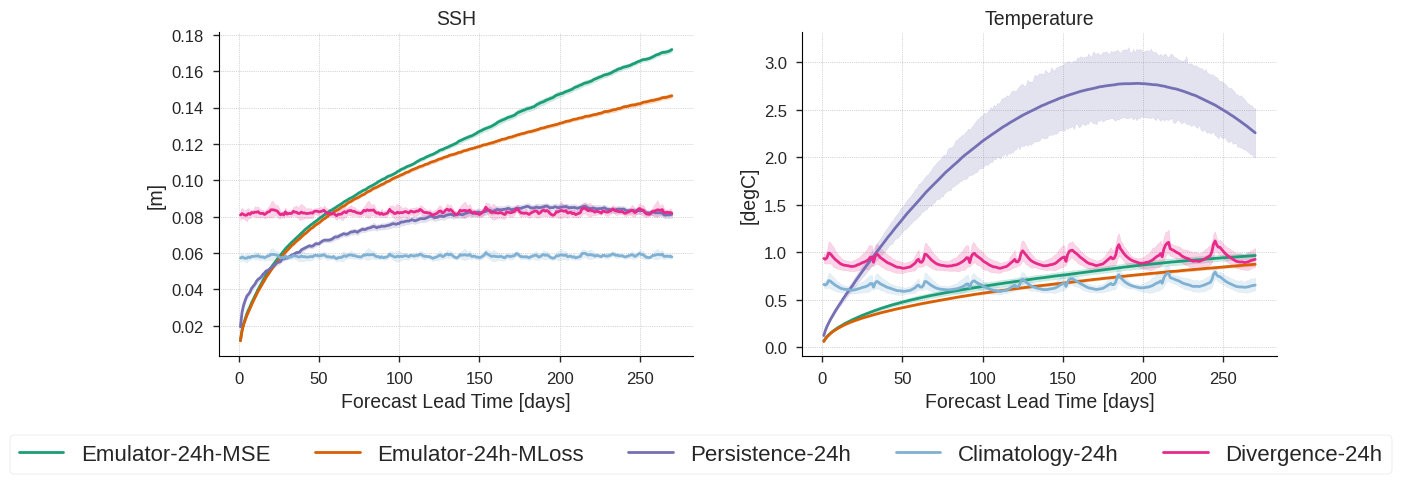

In [18]:
# Separate 2D and 3D variables to avoid list mutation issues
has_ssh = "SSH" in var_list
vars_3d = [v for v in var_list if v != "SSH"]
total_vars_to_plot = len(vars_3d) + 1 if has_ssh else len(vars_3d)*len(z_l)
ncols = 2 if total_vars_to_plot> 1 else 1 
nrows = math.ceil(total_vars_to_plot / ncols)

for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} ---")
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6 * (ncols if ncols > 0 else 1), 4 * nrows+1), squeeze=False)
    this_row = 0; this_col = 0
    
    # 1. Plot SSH (2D Variable)
    if has_ssh:
        print("Plotting SSH...")
        
        # Check if SSH is the only or the last row
        is_bottom = (nrows == 1)

        for config in MODELS_CONFIG:
            plot_model_data(
                ax=axs[this_row][this_col], model_config=config, truth_key=truth, var_key="SSH",
                metric=metric, forecast_days=PLOT_FORECAST_DAYS, z_val=None, 
                depth_unit=depth_unit, is_top_row=True, is_left_col=True, 
                is_bottom_row=is_bottom,
            )
        
        this_col += 1
        if (this_col%ncols == 0):
            this_row +=1
            this_col = 0

    # 2. Plot 3D Variables (Grid: Depth x Variable)
    # Check if this is the absolute bottom row of the entire figure
    is_bottom = (this_row == nrows-1)
        
    for i, var_name in enumerate(vars_3d):
        print(f"Variable: {var_name}")
            
        # Logic for labels
        is_top = (this_row == 0) # Top of visual grid
        is_left = (this_col == 0) # Only first column gets Y-axis label
            
        for config in MODELS_CONFIG:
            plot_model_data(
                ax=axs[this_row][this_col], model_config=config, truth_key=truth, var_key=var_name,
                metric=metric, forecast_days=PLOT_FORECAST_DAYS, z_val=None, depth_unit=depth_unit,
                is_top_row=is_top, is_left_col=is_left, is_bottom_row=is_bottom,
            )

        this_col += 1
        if (this_col%ncols == 0):
            this_row +=1
            this_col = 0
    
    # --- Finalize Figure ---
    # Remove individual legends
    for ax in fig.axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # Shared Legend
    handles, labels = [], []
    for ax in fig.axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    
    fig.legend(
        handles, labels, 
        loc='lower center', ncol=len(MODELS_CONFIG), 
        bbox_to_anchor=(0.5, 0.0),
    )

    #fig.subplots_adjust(bottom=0.15, top=0.95)
    
    # Remove the unused axes
    ax_flat = axs.flatten()
    for j in range(total_vars_to_plot, len(ax_flat)):
        fig.delaxes(ax_flat[j]) # Or, axs_flat[j].remove()
    
    plt.tight_layout(rect=[0, 0.1, 1, 1]) # (left, bottom, right, top)
    
    if SAVE_PLOT:
        figname = f"figureS6.png"
        if APPLY_LATITUDE_WEIGHTING:
            figname = f"LW-{figname}"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

## Compute the forecast horizon

In [18]:
# --- Find climatology index in MODELS_CONFIG ---
# In the below expression, the iterator using next() would return a single value, corresponding
# to the index of the MODELS_CONFIG list with the string "climatology" in the name 
clima_idx = next(i for i, c in enumerate(MODELS_CONFIG) if "climatology" in c["name"].lower())
clima_config = MODELS_CONFIG[clima_idx]
print(f"Using '{clima_config['name']}' as climatology reference. Found at the index {clima_idx}")

Using 'Climatology-24h' as climatology reference. Found at the index 3


In [19]:
# --- Compute forecast horizon ---
forecast_horizon = {}

for truth in TRUTHS:
    forecast_horizon[truth] = {}
    
    # Compute climatology RMSE once
    clima_sq_err = all_sq_error[clima_config["name"]][truth]

    # iterate over all variables
    for var_name in var_list:
        forecast_horizon[truth][var_name] = {}
            
        # Climatology RMSE for this variable
        clima_rmse = calculate_rmse(
            clima_sq_err[var_name], 
            apply_weighting=APPLY_LATITUDE_WEIGHTING,
            depth_level=z_l if "z_l" in clima_sq_err[var_name].dims else None,
            depth_unit=depth_unit,
            ).mean("time")  # average over init times: (lead_time,)

        # iterate over all models
        for model_config in MODELS_CONFIG:
            # if this is climatological model, pass
            if "climatology" in model_config["name"].lower():
                continue

            ## process this model: compute rmse and then compare against the clima errors
            model_name = model_config["name"]
            model_sq_err = all_sq_error[model_name][truth]
            model_rmse = calculate_rmse(
                model_sq_err[var_name],
                apply_weighting=APPLY_LATITUDE_WEIGHTING,
                depth_level=z_l if "z_l" in model_sq_err[var_name].dims else None,
                depth_unit=depth_unit,
            ).mean("time")  # (lead_time,)
                
            # Find first lead time where model RMSE exceeds climatology RMSE
            exceeds = model_rmse > clima_rmse
            if exceeds.any():
                horizon_td = model_rmse["lead_time"].where(exceeds, drop=True).values[0]
                horizon_days = horizon_td / np.timedelta64(1, 'D')
            else:
                horizon_days = None  # never exceeds climatology within forecast window
                
            forecast_horizon[truth][var_name][model_name] = horizon_days
            print(f"  {truth} | {var_name} | {model_name}: horizon = {horizon_days} days")
            

  Replay | SSH | Emulator-24h-MSE: horizon = 26.0 days
  Replay | SSH | Emulator-24h-MLoss: horizon = 27.0 days
  Replay | SSH | Persistence-24h: horizon = 31.0 days
  Replay | SSH | Divergence-24h: horizon = 1.0 days
  Replay | temp | Emulator-24h-MSE: horizon = 101.0 days
  Replay | temp | Emulator-24h-MLoss: horizon = 110.0 days
  Replay | temp | Persistence-24h: horizon = 17.0 days
  Replay | temp | Divergence-24h: horizon = 1.0 days
